<a href="https://colab.research.google.com/github/leonardeugenia-hash/TGF2026/blob/main/ingenieria_del_dato/datos3_borrador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Script 3 — Feature Engineering a nivel de canción



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

pd.set_option('display.max_columns', None)

def styled_table(df, caption=''):
    return (
        df.style
        .set_caption(caption)
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '13px'), ('font-weight', 'bold'), ('padding-bottom', '8px')]},
            {'selector': 'thead th',
             'props': [('background-color', '#1a3a5c'), ('color', 'white'),
                       ('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'tbody tr:nth-child(even)',
             'props': [('background-color', '#f0f4f8')]},
            {'selector': 'tbody tr:hover',
             'props': [('background-color', '#d6e4f0')]},
            {'selector': 'td, th',
             'props': [('padding', '6px 12px'), ('text-align', 'center')]},
        ])
        .format(precision=2)
    )



## 1. CARGA  DE df_spotify_clean del script 1


In [ ]:

df = pd.read_csv('dataset_canciones_limpio.csv')

---
## 2. LIMPIEZA DE years_since_release NEGATIVOS
Valores negativos = la canción tiene fecha de lanzamiento posterior al año en que entró en la lista.  
Son errores de la API de Spotify → los tratamos antes de modelar.

In [ ]:
print('=' * 55)
print('YEARS_SINCE_RELEASE NEGATIVOS')
print('=' * 55)

negativos = df[df['years_since_release'] < 0]
print(f'Canciones con years_since_release negativo: {len(negativos)} ({len(negativos)/len(df)*100:.1f}% del total)')

if len(negativos) > 0:
    tabla_neg = negativos[['year', 'track_name', 'artist_name', 'release_year', 'years_since_release']].sort_values('years_since_release').copy()
    tabla_neg.columns = ['Año', 'Canción', 'Artista', 'Año lanzamiento', 'Years since release']
    display(styled_table(tabla_neg.reset_index(drop=True),
        f'Canciones con years_since_release negativo — {len(negativos)} casos')
        .format({'Año': '{:.0f}', 'Año lanzamiento': '{:.0f}', 'Years since release': '{:.2f}'}))

df.loc[df['years_since_release'] < 0, 'years_since_release'] = 0
print(f'\n→ Imputados a 0. Nuevos negativos: {(df["years_since_release"] < 0).sum()}')


YEARS_SINCE_RELEASE NEGATIVOS
Canciones con years_since_release negativo: 65 (5.5% del total)


,Año,Canción,Artista,Año lanzamiento,Years since release
0,2012,Tu jardín con enanitos,Roze Oficial,2025,-13.00
1,2015,I Really Like You,Carly Rae Jepsen,2025,-10.00
2,2015,King,Olly Alexander (Years & Years),2023,-8.00
3,2011,Si No Te Hubieras Ido,Tamara,2019,-8.00
4,2010,Todos los Besos,Los Rebujitos,2016,-6.00
5,2015,Earned It (Fifty Shades Of Grey),The Weeknd,2021,-6.00
6,2013,Comiendote a Besos,Rozalén,2018,-5.00
7,2015,Love Me Like You Do,Ellie Goulding,2018,-3.00
8,2015,Ain't Nobody (Loves Me Better) (feat. Jasmine Thompson),Felix Jaehn,2018,-3.00
9,2020,A Un Paso De La Luna,Ana Mena,2023,-3.00



→ Imputados a 0. Nuevos negativos: 0


---
## 3. AGRUPACIÓN DE GÉNEROS (genre_group_agrupado)
61 géneros son demasiados para K-Means y PCA. Los agrupamos en categorías manejables.

In [ ]:
print('=' * 55)
print('AGRUPACIÓN DE GÉNEROS')
print('=' * 55)
print(f'\nGéneros únicos antes: {df["genre_group"].nunique()}')

vc_before = df['genre_group'].value_counts().head(20).reset_index()
vc_before.columns = ['Género', 'N canciones']
display(styled_table(vc_before, 'Top 20 géneros antes de agrupar').format({'N canciones': '{:.0f}'}))

mapa_generos = {
    'reggaeton': 'urbano_latino', 'latin pop': 'urbano_latino', 'trap latino': 'urbano_latino',
    'latin': 'urbano_latino', 'reggaeton colombiano': 'urbano_latino', 'reggaeton mexa': 'urbano_latino',
    'latin alternative': 'urbano_latino', 'latin arena pop': 'urbano_latino',
    'corridos tumbados': 'urbano_latino', 'cubaton': 'urbano_latino', 'dembow': 'urbano_latino',
    'cumbia pop': 'urbano_latino', 'techengue': 'urbano_latino', 'cuarteto': 'urbano_latino',
    'tropical': 'urbano_latino',
    'spanish pop': 'pop_espanol', 'pop': 'pop_espanol', 'pop nacional': 'pop_espanol',
    'electropop': 'pop_espanol', 'dance pop': 'pop_espanol', 'pop rock': 'pop_espanol',
    'teen pop': 'pop_espanol', 'baroque pop': 'pop_espanol', 'art pop': 'pop_espanol',
    'flamenco': 'flamenco_raices', 'nueva flamenco': 'flamenco_raices', 'rumba': 'flamenco_raices',
    'spanish folk': 'flamenco_raices', 'cantautor': 'flamenco_raices', 'cancion melódica': 'flamenco_raices',
    'indie': 'rock_indie', 'indie pop': 'rock_indie', 'indie rock': 'rock_indie',
    'rock': 'rock_indie', 'rock en espanol': 'rock_indie', 'alternative rock': 'rock_indie',
    'neo-psychedelic': 'rock_indie', 'spanish indie pop': 'rock_indie',
    'electronic': 'electronica', 'edm': 'electronica', 'house': 'electronica',
    'deep house': 'electronica', 'tropical house': 'electronica',
    'progressive electro house': 'electronica',
    'k-pop': 'internacional', 'uk pop': 'internacional', 'canadian pop': 'internacional',
    'pop urbaine': 'internacional', 'r&b': 'internacional', 'soul': 'internacional',
    'hip hop': 'internacional', 'rap': 'internacional',
}

df['genre_group_agrupado'] = df['genre_group'].map(mapa_generos)

sin_mapear = df[df['genre_group_agrupado'].isna() & (df['genre_group'] != 'unknown')]['genre_group'].value_counts()
if len(sin_mapear) > 0:
    df_sin = sin_mapear.reset_index()
    df_sin.columns = ['Género sin mapear', 'N canciones']
    display(styled_table(df_sin, f'⚠️ Géneros sin mapear — {len(sin_mapear)} únicos').format({'N canciones': '{:.0f}'}))

df.loc[df['genre_group'] == 'unknown', 'genre_group_agrupado'] = 'unknown'
df['genre_group_agrupado'] = df['genre_group_agrupado'].fillna('otros')

print(f'\nGéneros únicos después: {df["genre_group_agrupado"].nunique()}')
vc_after = df['genre_group_agrupado'].value_counts().reset_index()
vc_after.columns = ['Género agrupado', 'N canciones']
display(styled_table(vc_after, 'Distribución tras agrupación').format({'N canciones': '{:.0f}'}))


AGRUPACIÓN DE GÉNEROS

Géneros únicos antes: 61


,Género,N canciones
0,unknown,462
1,reggaeton,203
2,flamenco,97
3,latin pop,80
4,indie,29
5,flamenco pop,27
6,argentine trap,26
7,colombian pop,25
8,latin,22
9,singer-songwriter,21


,Género sin mapear,N canciones
0,flamenco pop,27
1,argentine trap,26
2,colombian pop,25
3,singer-songwriter,21
4,flamenco urbano,13
5,urbano latino,13
6,soft pop,12
7,trova,9
8,rock en español,9
9,neoperreo,6



Géneros únicos después: 8


,Género agrupado,N canciones
0,unknown,462
1,urbano_latino,332
2,otros,226
3,flamenco_raices,97
4,rock_indie,29
5,electronica,27
6,pop_espanol,9
7,internacional,3


---
## 4. CREACIÓN DE VARIABLES DERIVADAS

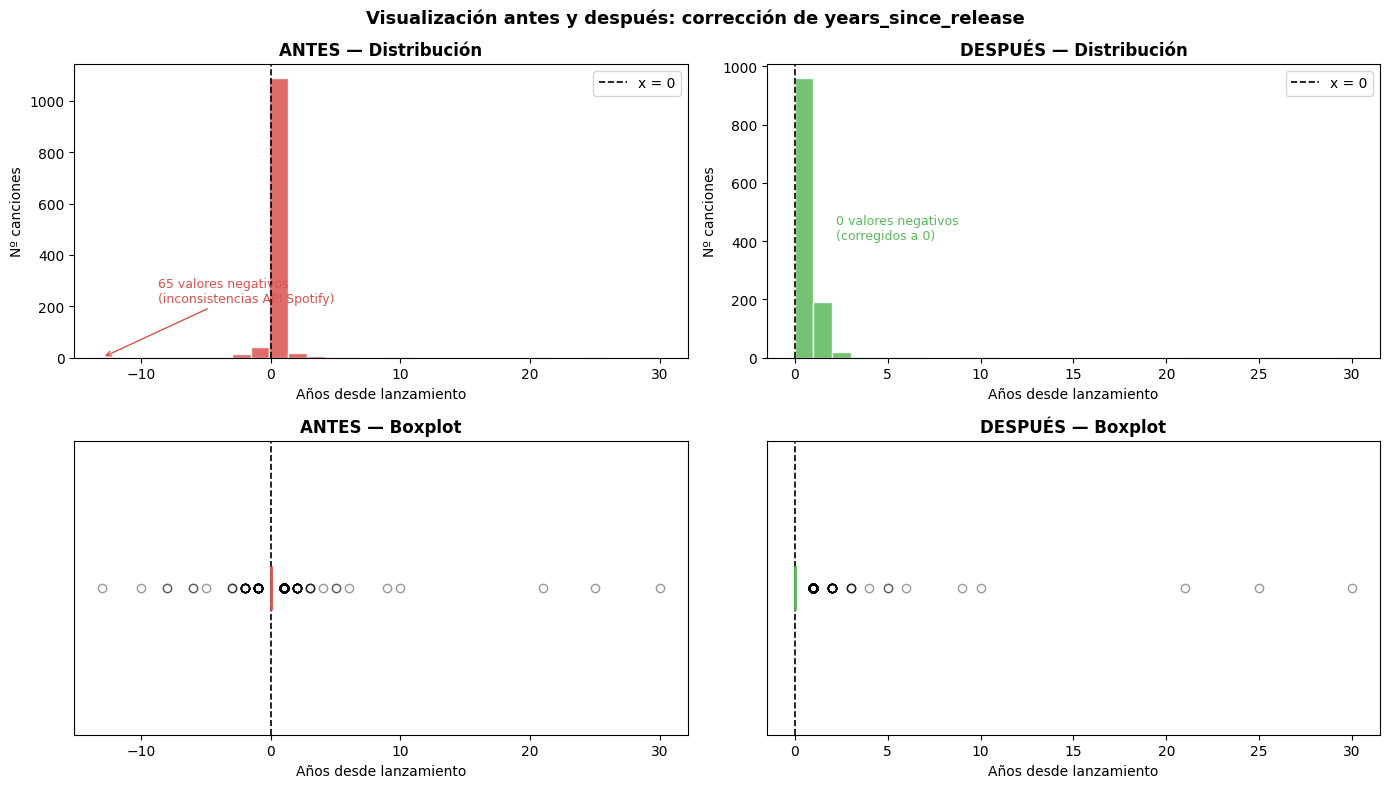

,Métrica,ANTES,DESPUÉS
0,Nº valores negativos,65.00,0.00
1,Mínimo,-13.00,0.00
2,Máximo,30.00,30.00
3,Media,0.19,0.30


In [ ]:
# ══════════════════════════════════════════════════════════
# VISUALIZACIÓN ANTES / DESPUÉS — years_since_release
# Reconstruimos el "antes" desde las columnas originales
# porque el clip ya puede haberse aplicado al df
# ══════════════════════════════════════════════════════════

# ANTES: recalculamos years_since_release sin corrección
years_original = df['year'].astype(float) - df['release_year'].astype(float)

# DESPUÉS: aplicamos la misma lógica que el clip
years_corregido = years_original.clip(lower=0)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Visualización antes y después: corrección de years_since_release',
             fontsize=13, fontweight='bold')

# ── ANTES: histograma ──────────────────────────────────────
axes[0, 0].hist(years_original.dropna(), bins=30,
                color='#d9534f', edgecolor='white', alpha=0.85)
axes[0, 0].axvline(0, color='black', linestyle='--', linewidth=1.2, label='x = 0')
axes[0, 0].set_title('ANTES — Distribución', fontweight='bold')
axes[0, 0].set_xlabel('Años desde lanzamiento')
axes[0, 0].set_ylabel('Nº canciones')
axes[0, 0].legend()
n_neg = (years_original < 0).sum()
x_neg = years_original.min()
axes[0, 0].annotate(f'{n_neg} valores negativos\n(inconsistencias API Spotify)',
                    xy=(x_neg, 1),
                    xytext=(40, 40), textcoords='offset points',
                    fontsize=9, color='#d9534f',
                    arrowprops=dict(arrowstyle='->', color='#d9534f'))

# ── ANTES: boxplot ─────────────────────────────────────────
axes[1, 0].boxplot(years_original.dropna(), vert=False,
                   patch_artist=True,
                   boxprops=dict(facecolor='#f5c6c5', color='#d9534f'),
                   medianprops=dict(color='#d9534f', linewidth=2),
                   whiskerprops=dict(color='#d9534f'),
                   capprops=dict(color='#d9534f'),
                   flierprops=dict(marker='o', color='#d9534f', alpha=0.4))
axes[1, 0].axvline(0, color='black', linestyle='--', linewidth=1.2)
axes[1, 0].set_title('ANTES — Boxplot', fontweight='bold')
axes[1, 0].set_xlabel('Años desde lanzamiento')
axes[1, 0].set_yticks([])

# ── DESPUÉS: histograma ────────────────────────────────────
axes[0, 1].hist(years_corregido.dropna(), bins=30,
                color='#5cb85c', edgecolor='white', alpha=0.85)
axes[0, 1].axvline(0, color='black', linestyle='--', linewidth=1.2, label='x = 0')
axes[0, 1].set_title('DESPUÉS — Distribución', fontweight='bold')
axes[0, 1].set_xlabel('Años desde lanzamiento')
axes[0, 1].set_ylabel('Nº canciones')
axes[0, 1].legend()
axes[0, 1].annotate(f'0 valores negativos\n(corregidos a 0)',
                    xy=(0, axes[0, 1].get_ylim()[1] * 0.5),
                    xytext=(30, -20), textcoords='offset points',
                    fontsize=9, color='#5cb85c')

# ── DESPUÉS: boxplot ───────────────────────────────────────
axes[1, 1].boxplot(years_corregido.dropna(), vert=False,
                   patch_artist=True,
                   boxprops=dict(facecolor='#c8e6c9', color='#5cb85c'),
                   medianprops=dict(color='#5cb85c', linewidth=2),
                   whiskerprops=dict(color='#5cb85c'),
                   capprops=dict(color='#5cb85c'),
                   flierprops=dict(marker='o', color='#5cb85c', alpha=0.4))
axes[1, 1].axvline(0, color='black', linestyle='--', linewidth=1.2)
axes[1, 1].set_title('DESPUÉS — Boxplot', fontweight='bold')
axes[1, 1].set_xlabel('Años desde lanzamiento')
axes[1, 1].set_yticks([])

plt.tight_layout()
plt.savefig('antes_despues_years_since_release.png', dpi=150, bbox_inches='tight')
plt.show()

# ── TABLA RESUMEN ──────────────────────────────────────────
resumen_corr = pd.DataFrame({
    'Métrica': ['Nº valores negativos', 'Mínimo', 'Máximo', 'Media'],
    'ANTES': [
        int((years_original < 0).sum()),
        round(float(years_original.min()), 2),
        round(float(years_original.max()), 2),
        round(float(years_original.mean()), 2)
    ],
    'DESPUÉS': [
        int((years_corregido < 0).sum()),
        round(float(years_corregido.min()), 2),
        round(float(years_corregido.max()), 2),
        round(float(years_corregido.mean()), 2)
    ]
})
display(styled_table(resumen_corr, 'Resumen de la corrección — years_since_release'))

In [ ]:

df['is_urbano_latino']       = (df['genre_group_agrupado'] == 'urbano_latino').astype(int)
df['is_lanzamiento_reciente'] = (df['years_since_release'] <= 1).astype(int)
df['explicit']               = df['explicit'].astype(int)
df['decada_lanzamiento']     = (df['release_year'].astype(float) // 10 * 10).astype('Int64')
p75 = df['artist_popularity'].quantile(0.75)
df['is_artista_top']         = (df['artist_popularity'] > p75).astype(int)

def mes_a_temporada(mes):
    if pd.isna(mes): return np.nan
    mes = int(mes)
    if mes in [12, 1, 2]: return 'invierno'
    if mes in [3, 4, 5]:  return 'primavera'
    if mes in [6, 7, 8]:  return 'verano'
    return 'otono'

df['temporada_lanzamiento'] = df['release_month'].apply(mes_a_temporada)

nuevas = ['is_urbano_latino', 'is_lanzamiento_reciente', 'explicit',
          'decada_lanzamiento', 'is_artista_top', 'temporada_lanzamiento']
resumen_vars = pd.DataFrame({
    'Variable': nuevas,
    'Valores únicos': [df[v].nunique() for v in nuevas],
    'Nulos': [df[v].isna().sum() for v in nuevas],
})
display(styled_table(resumen_vars, 'Variables derivadas creadas').format({'Valores únicos': '{:.0f}', 'Nulos': '{:.0f}'}))
print(f'\nShape tras variables derivadas: {df.shape}')


,Variable,Valores únicos,Nulos
0,is_urbano_latino,2,0
1,is_lanzamiento_reciente,2,0
2,explicit,2,0
3,decada_lanzamiento,5,0
4,is_artista_top,2,0
5,temporada_lanzamiento,4,10



Shape tras variables derivadas: (1185, 22)


---
## 5. ENCODING DE VARIABLES CATEGÓRICAS
Convertimos `genre_group_agrupado` y `temporada_lanzamiento` a variables dummy para los modelos

In [ ]:

dummies_genero = pd.get_dummies(df['genre_group_agrupado'], prefix='genero', drop_first=False, dtype=int)
df['temporada_lanzamiento'] = df['temporada_lanzamiento'].fillna('sin_fecha')
dummies_temporada = pd.get_dummies(df['temporada_lanzamiento'], prefix='temporada', drop_first=False, dtype=int)

resumen_enc = pd.DataFrame({
    'Tipo': ['Género agrupado', 'Temporada lanzamiento'],
    'Columnas generadas': [dummies_genero.columns.tolist(), dummies_temporada.columns.tolist()]
})
display(styled_table(resumen_enc, 'Encoding one-hot — columnas generadas'))


,Tipo,Columnas generadas
0,Género agrupado,"['genero_electronica', 'genero_flamenco_raices', 'genero_internacional', 'genero_otros', 'genero_pop_espanol', 'genero_rock_indie', 'genero_unknown', 'genero_urbano_latino']"
1,Temporada lanzamiento,"['temporada_invierno', 'temporada_otono', 'temporada_primavera', 'temporada_sin_fecha', 'temporada_verano']"


---
## 6. SELECCIÓN DE VARIABLES PARA MODELOS
Definimos las columnas que entran en K-Means y PCA

In [ ]:


vars_numericas = ['popularity', 'duration_sec', 'artist_popularity', 'years_since_release']
vars_binarias  = ['explicit', 'is_urbano_latino', 'is_lanzamiento_reciente', 'is_artista_top']

df_modelos_base = pd.concat([
    df[['year'] + vars_numericas + vars_binarias].reset_index(drop=True),
    dummies_genero.reset_index(drop=True),
    dummies_temporada.reset_index(drop=True),
], axis=1)

resumen_sel = pd.DataFrame({
    'Grupo': ['Numéricas continuas (escalar)', 'Binarias (no escalar)', 'Dummies género', 'Dummies temporada'],
    'N variables': [len(vars_numericas), len(vars_binarias), dummies_genero.shape[1], dummies_temporada.shape[1]],
    'Variables': [str(vars_numericas), str(vars_binarias),
                  str(dummies_genero.columns.tolist()), str(dummies_temporada.columns.tolist())]
})
display(styled_table(resumen_sel, 'Selección de variables para modelos').format({'N variables': '{:.0f}'}))
print(f'\nShape antes de escalar: {df_modelos_base.shape}')
print(f'Nulos: {df_modelos_base.isnull().sum().sum()}')


,Grupo,N variables,Variables
0,Numéricas continuas (escalar),4,"['popularity', 'duration_sec', 'artist_popularity', 'years_since_release']"
1,Binarias (no escalar),4,"['explicit', 'is_urbano_latino', 'is_lanzamiento_reciente', 'is_artista_top']"
2,Dummies género,8,"['genero_electronica', 'genero_flamenco_raices', 'genero_internacional', 'genero_otros', 'genero_pop_espanol', 'genero_rock_indie', 'genero_unknown', 'genero_urbano_latino']"
3,Dummies temporada,5,"['temporada_invierno', 'temporada_otono', 'temporada_primavera', 'temporada_sin_fecha', 'temporada_verano']"



Shape antes de escalar: (1185, 22)
Nulos: 0


---
## 7. ESCALADO DE VARIABLES NUMÉRICAS
StandardScaler para PCA y K-Means (media=0, std=1).  
K-Means es muy sensible a escala — sin esto, `duration_sec` dominaría por sus valores grandes.

In [ ]:


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_modelos = df_modelos_base.copy()

cols_escalar = [c for c in vars_numericas if c in df_modelos.columns]
df_modelos[cols_escalar] = scaler.fit_transform(df_modelos[cols_escalar])

desc_scaled = df_modelos[cols_escalar].describe().T.round(2)
desc_scaled.columns = ['N', 'Media', 'Desv. tip.', 'Min', 'P25', 'Mediana', 'P75', 'Max']
display(
    desc_scaled.style
    .set_caption('Estadísticas tras escalar (media ≈ 0, std ≈ 1)')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '13px'), ('font-weight', 'bold'), ('padding-bottom', '8px')]},
        {'selector': 'thead th', 'props': [('background-color', '#1a3a5c'), ('color', 'white'),
                                            ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#f0f4f8')]},
        {'selector': 'tbody tr:hover', 'props': [('background-color', '#d6e4f0')]},
        {'selector': 'td, th', 'props': [('padding', '6px 12px'), ('text-align', 'center')]},
    ])
    .format({'N': '{:.0f}', 'Media': '{:.2f}', 'Desv. tip.': '{:.2f}',
             'Min': '{:.2f}', 'P25': '{:.2f}', 'Mediana': '{:.2f}', 'P75': '{:.2f}', 'Max': '{:.2f}'})
)
print(f'\nShape final dataset modelos: {df_modelos.shape}')
print(f'Nulos: {df_modelos.isnull().sum().sum()}')


,N,Media,Desv. tip.,Min,P25,Mediana,P75,Max
popularity,1185,0.00,1.00,-2.85,-0.67,0.11,0.79,1.83
duration_sec,1185,0.00,1.00,-2.63,-0.63,-0.08,0.48,7.48
artist_popularity,1185,0.00,1.00,-3.96,-0.71,0.15,0.83,2.06
years_since_release,1185,0.00,1.00,-0.21,-0.21,-0.21,-0.21,20.68



Shape final dataset modelos: (1185, 22)
Nulos: 0


---
## 8. VALIDACIÓN FINAL

In [ ]:

cols_limpias = [
    'year', 'track_name', 'artist_name', 'release_year', 'release_month',
    'popularity', 'duration_sec', 'artist_popularity', 'explicit',
    'years_since_release', 'genre_group', 'genre_group_agrupado',
    'is_urbano_latino', 'is_lanzamiento_reciente', 'is_artista_top',
    'decada_lanzamiento', 'temporada_lanzamiento'
]
df_limpio = df[[c for c in cols_limpias if c in df.columns]].copy()

# Resumen de ambos datasets
resumen_ds = pd.DataFrame({
    'Dataset': ['df_limpio (sin escalar)', 'df_modelos (escalado)'],
    'Filas': [df_limpio.shape[0], df_modelos.shape[0]],
    'Columnas': [df_limpio.shape[1], df_modelos.shape[1]],
    'Nulos': [df_limpio.isnull().sum().sum(), df_modelos.isnull().sum().sum()],
})
display(styled_table(resumen_ds, 'Resumen — Datasets generados').format({'Filas': '{:.0f}', 'Columnas': '{:.0f}', 'Nulos': '{:.0f}'}))

# Distribución genre_group_agrupado
vc_gen = df_limpio['genre_group_agrupado'].value_counts().reset_index()
vc_gen.columns = ['Género agrupado', 'N canciones']
display(styled_table(vc_gen, 'Distribución final — genre_group_agrupado').format({'N canciones': '{:.0f}'}))

# Comprobación years_since_release
check_ysr = pd.DataFrame({
    'Métrica': ['Negativos', 'Mínimo', 'Máximo', 'Media'],
    'Valor': [
        (df_limpio['years_since_release'] < 0).sum(),
        df_limpio['years_since_release'].min(),
        df_limpio['years_since_release'].max(),
        round(df_limpio['years_since_release'].mean(), 2),
    ]
})
display(styled_table(check_ysr, 'years_since_release').format({'Valor': '{:.2f}'}))


,Dataset,Filas,Columnas,Nulos
0,df_limpio (sin escalar),1185,17,10
1,df_modelos (escalado),1185,22,0


,Género agrupado,N canciones
0,unknown,462
1,urbano_latino,332
2,otros,226
3,flamenco_raices,97
4,rock_indie,29
5,electronica,27
6,pop_espanol,9
7,internacional,3


,Métrica,Valor
0,Negativos,0.00
1,Mínimo,0.00
2,Máximo,30.00
3,Media,0.30


/tmp/ipykernel_6718/465432468.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpio, x='genre_group_agrupado', y='popularity',


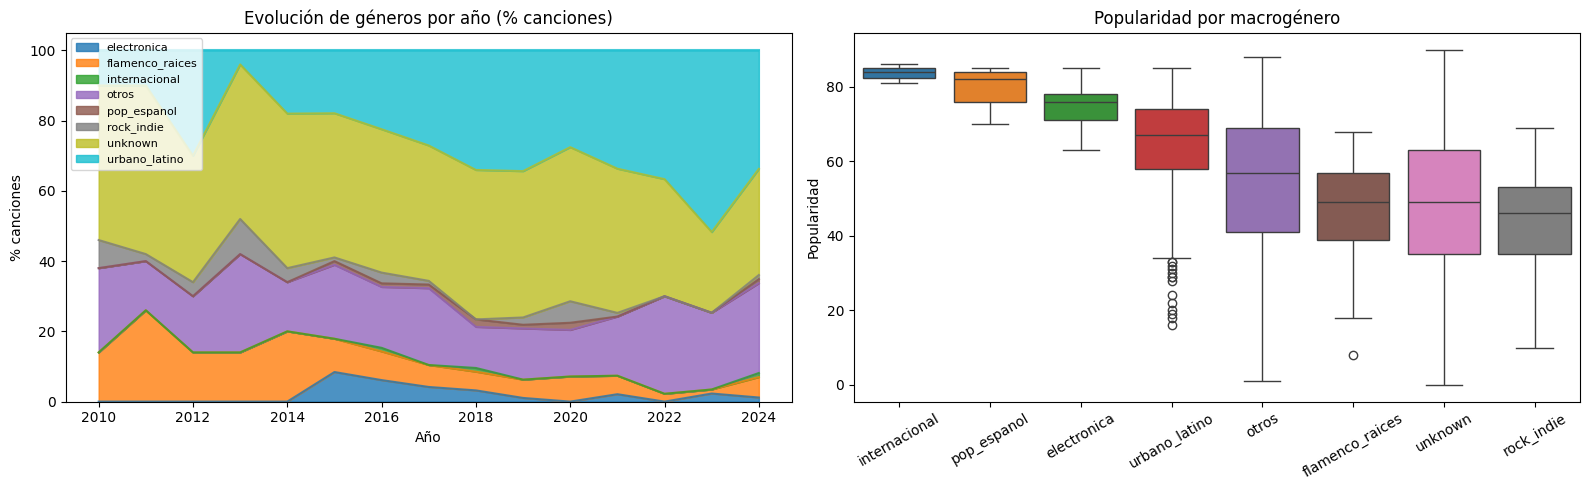

In [ ]:
# Visualización: evolución del género agrupado por año
genero_año = (df_limpio.groupby(['year', 'genre_group_agrupado'])
              .size()
              .reset_index(name='n')
              .pivot(index='year', columns='genre_group_agrupado', values='n')
              .fillna(0))

genero_año_pct = genero_año.div(genero_año.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

genero_año_pct.plot(kind='area', stacked=True, ax=ax1, colormap='tab10', alpha=0.8)
ax1.set_title('Evolución de géneros por año (% canciones)', fontsize=12)
ax1.set_xlabel('Año')
ax1.set_ylabel('% canciones')
ax1.legend(loc='upper left', fontsize=8)

# Distribución de popularidad por género
orden = df_limpio.groupby('genre_group_agrupado')['popularity'].median().sort_values(ascending=False).index
sns.boxplot(data=df_limpio, x='genre_group_agrupado', y='popularity',
            order=orden, ax=ax2, palette='tab10')
ax2.set_title('Popularidad por macrogénero', fontsize=12)
ax2.set_xlabel('')
ax2.set_ylabel('Popularidad')
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

---
## 9. GUARDADO

In [ ]:
print('=' * 55)
print('GUARDADO')
print('=' * 55)

df_limpio.to_csv('dataset_canciones_limpio.csv', index=False)
print('✅ dataset_canciones_limpio.csv')

df_modelos.to_csv('dataset_canciones_modelos.csv', index=False)
print('✅ dataset_canciones_modelos.csv')

resumen_final = pd.DataFrame({
    'Métrica': ['Canciones', 'Año inicio', 'Año fin',
                'Columnas dataset limpio', 'Columnas dataset modelos', 'Nulos dataset modelos'],
    'Valor': [
        len(df_limpio),
        int(df_limpio['year'].min()),
        int(df_limpio['year'].max()),
        df_limpio.shape[1],
        df_modelos.shape[1],
        df_modelos.isnull().sum().sum(),
    ]
})
display(styled_table(resumen_final, 'Resumen del guardado').format({'Valor': '{:.0f}'}))

df_cols = pd.DataFrame({'Columna': df_modelos.columns.tolist()})
display(styled_table(df_cols, 'Columnas — dataset_canciones_modelos.csv'))


GUARDADO
✅ dataset_canciones_limpio.csv
✅ dataset_canciones_modelos.csv


,Métrica,Valor
0,Canciones,1185
1,Año inicio,2010
2,Año fin,2024
3,Columnas dataset limpio,17
4,Columnas dataset modelos,22
5,Nulos dataset modelos,0


,Columna
0,year
1,popularity
2,duration_sec
3,artist_popularity
4,years_since_release
5,explicit
6,is_urbano_latino
7,is_lanzamiento_reciente
8,is_artista_top
9,genero_electronica
